# **1. Project Overview**

## 1.1 Business Objective

The objective of this project is building machine learning models that can accurately predict housing prices based on property characteristics.
Accurate housing price predictions can support real estate agencies, buyers, sellers, and property investors in making informed decisions.
The model help find key factors influencing house prices and improve pricing consistency in the housing market.

## 1.2 Experiment Objective

The objective of this experiment is building a Random Forest Regression Model to predict housing prices. Random Forest is an ensemble learning method that combines multiple decision trees and can capture complex non-linear relationships between property characteristics and housing prices. The model will be evaluated and compared with the previously developed Linear Regression and ElasticNet models.

## 1.3 Model Hypothesis

The Random Forest model is expected to outperform previous models because it can capture non-linear relationships and interactions between variables. Housing prices are influenced by complex combinations of property characteristics, location, and quality factors that may not be fully represented by linear models. Therefore, Random Forest is expected to achieve lower prediction errors and higher R2 scores on unseen data.

# **2. Load Dataset**

In [3]:
import pandas as pd
import numpy as np

In [4]:
X_train = pd.read_csv('../data/X_train_processed.csv')
X_val = pd.read_csv('../data/X_val_processed.csv')
X_test = pd.read_csv('../data/X_test_processed.csv')

y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_val = pd.read_csv('../data/y_val.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

# **3. Model Development**

## 3.1 Import Algorithm

In [5]:
# Import RandomForestRegressor from sklearn
from sklearn.ensemble import RandomForestRegressor

## 3.2 Set Hyperparameters

In [6]:
# Define the range of hyperparameters
n_estimators_values = [100, 300, 500]
max_depth_values = [None, 10, 20, 30]

## 3.3 Train Model

In [7]:
# Import RMSE, RAE, R2 score from sklearn
from sklearn.metrics import root_mean_squared_error as rmse
from sklearn.metrics import mean_absolute_error as mae
from sklearn.metrics import r2_score

In [8]:
# Fit Model
results = []

for n_estimators in n_estimators_values:
    for max_depth in max_depth_values:
        rf = RandomForestRegressor(n_estimators = n_estimators, max_depth = max_depth, random_state = 42)
        rf.fit(X_train, y_train)
        
        y_val_pred = rf.predict(X_val)
        
        results.append({
            'n_estimators': n_estimators,
            'max_depth': max_depth,
            'RMSE': rmse(y_val, y_val_pred),
            'MAE': mae(y_val, y_val_pred),
            'R2_Score': r2_score(y_val, y_val_pred)
        })
        
results_df = pd.DataFrame(results)
results_df.sort_values(by = 'RMSE') 

,n_estimators,max_depth,RMSE,MAE,R2_Score
0,100,NaN,0.115776,0.080898,0.925460
3,100,30.0,0.115900,0.081052,0.925300
2,100,20.0,0.116075,0.081104,0.925075
4,300,NaN,0.116294,0.080658,0.924792
6,300,20.0,0.116338,0.080731,0.924735
7,300,30.0,0.116397,0.080786,0.924659
8,500,NaN,0.116503,0.080675,0.924522
10,500,20.0,0.116520,0.080605,0.924499
11,500,30.0,0.116548,0.080731,0.924463
1,100,10.0,0.117960,0.083290,0.922621


In [9]:
# Select the Best Model
best_rf = RandomForestRegressor(n_estimators=100, max_depth = 20, random_state=42)

best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

The model with 'max_depth=None' achieved the lowest validation RMSE. However, the performance difference between max_depth=None and max_depth=20 was negligible. Since shallower trees generally reduce model complexity and the risk of overfitting, 'max_depth=20' was selected as the final model for further evaluation.

## 3.4 Generate Predictions

In [10]:
y_train_pred = best_rf.predict(X_train)
y_val_pred = best_rf.predict(X_val)
y_test_pred = best_rf.predict(X_test)

# **4. Model Evaluation**

## 4.1 Technical Performance

In [11]:
# Check the Random Forest Regressor performance
model_results = pd.DataFrame({
    'Dataset': ['Train', 'Val', 'Test'],
    'RMSE': [
        rmse(y_train, y_train_pred),
        rmse(y_val, y_val_pred),
        rmse(y_test, y_test_pred)
    ],
    'MAE': [
        mae(y_train, y_train_pred),
        mae(y_val, y_val_pred),
        mae(y_test, y_test_pred)
    ],
    'R2_Score': [
        r2_score(y_train, y_train_pred),
        r2_score(y_val, y_val_pred),
        r2_score(y_test, y_test_pred)
    ]
})

model_results

,Dataset,RMSE,MAE,R2_Score
0,Train,0.058586,0.039953,0.978669
1,Val,0.116075,0.081104,0.925075
2,Test,0.155482,0.104032,0.872888


## 4.2 Prediction Visualisation

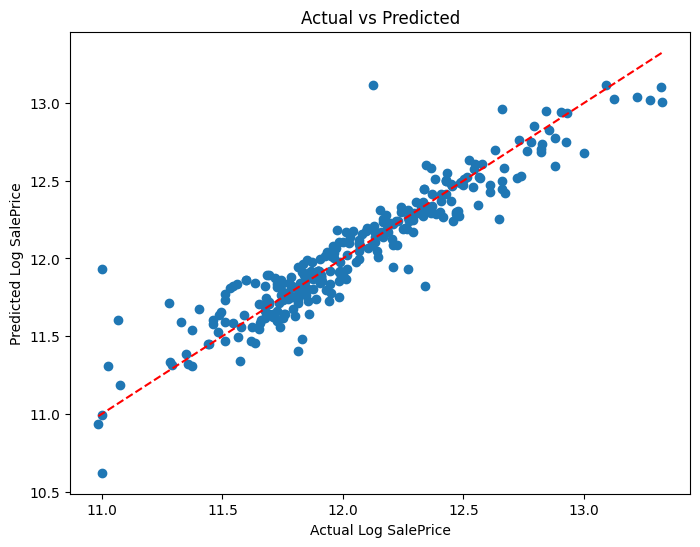

In [12]:
# Scatterplot of Actual Log SalePrice vs Predicted Log SalePrice
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_test_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel('Actual Log SalePrice')
plt.ylabel('Predicted Log SalePrice')
plt.title('Actual vs Predicted')

plt.show()

The Actual vs Predicted plot shows a strong relationship between the observed and predicted housing prices. Most predictions follow the ideal prediction line, showing that the Random Forest model captures important patterns within the data. However, several larger prediction errors particularly for some extreme housing prices remain.

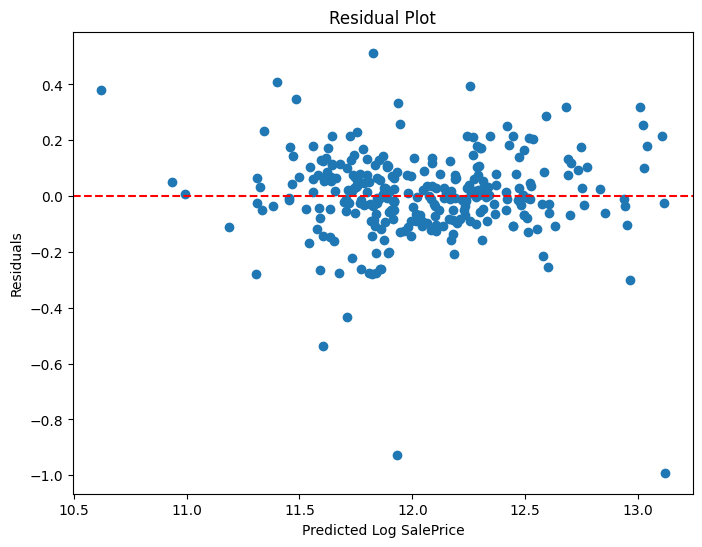

In [15]:
# Residual plot
residuals = y_test - y_test_pred

plt.figure(figsize=(8,6))

plt.scatter(y_test_pred, residuals)

plt.axhline(color = 'red', ls = '--')

plt.xlabel('Predicted Log SalePrice')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

The model captures much of the variation in housing prices as the residuals are generally distributed around zero. However, several larger residuals are present. It shows that the model struggles to accurately predict certain observations and may exhibit some degree of overfitting.

## 4.3 Model Interpretation

In [16]:
# Extract Top 10 Important Features
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf.feature_importances_
})

importance_df.sort_values(
    by = 'Importance',
    ascending = False
).head(10)

,Feature,Importance
0,num__Overall Qual,0.593607
1,num__Gr Liv Area,0.111088
3,num__Garage Area,0.058955
4,num__Total Bsmt SF,0.051187
2,num__Garage Cars,0.043995
5,num__1st Flr SF,0.041675
6,num__Year Built,0.037792
11,ord__Kitchen Qual,0.011502
46,nom__MS Zoning_RM,0.007957
7,num__Full Bath,0.007671


The Random Forest model identified `Overall Qual` as the most important predictor of housing prices. `Gr Liv Area` was the second most influential variable, followed by `Garage Area` and `Total Bsmt SF`. These findings are broadly consistent with the results from the EDA and previous regression models and highlight the importance of property quality and size in determining housing values.

## 4.4 Business Interpretation

The Random Forest model shows that overall property quality is the strongest key of housing prices. These important features indicates that both property quality and usable living area are key factors influencing market value. Such insights may support real estate agencies and property investors in understanding the characteristics most strongly associated with higher housing prices.

# **5. Experiment Outcomes**

## 5.1 Key Findings

Random Forest identified `Overall Qual` and `Gr Liv Area` as the most influential predictors of housing prices. While this model captured important patterns within the data, the model did not outperform Linear Regression on the test dataset and exhibited signs of overfitting.

## 5.2 Hypothesis Evaluation

**The hypothesis was not supported.** Although Random Forest was expected to outperform the linear models by capturing complex non-linear relationships, its test performance was slightly lower than both Linear Regression and ElasticNet. Because the selected features already captured much of the underlying relationship in a relatively linear manner, the model achieved extremely strong training performance but showed signs of overfitting.

## 5.3 Limitations

- Although Random Forest successfully captured important patterns within the data, the model exhibited signs of overfitting, as indicated by the substantial difference between training and test performance.
- Only a subset of available features was included in the modelling process and potentially useful information may have been excluded during feature selection. More advanced ensemble methods may improve predictive performance while maintaining better generalisation.

## 5.4 Next Experiment

The next experiment will evaluate an XGBoost Regression model. XGBoost is a boosting-based ensemble method that builds trees sequentially and often achieves stronger predictive performance than Random Forest by reducing prediction errors iteratively. The model will be compared against the current Random Forest, ElasticNet, and Linear Regression models to determine whether boosting can improve predictive accuracy and generalisation.